# Banana Ripeness — DINOv3 vs ConvNeXt → KMeans

Same clean, bg-removed pool as `banana-clean.ipynb`; only the embedding changes.
DINOv3 is self-supervised (no ImageNet labels), so its features should keep colour / texture / damage cues that the label-trained ConvNeXt collapses into "banana".

**Requires:** `banana-clean.ipynb` steps 1–5 already run (reads `NOBG_DIR`).

1. Load the bg-removed pool + labels, filename prefix (source), original split (augmented or not).
2. Embed: ConvNeXt-Tiny barebone (baseline), DINOv3 ViT-S+/16 (CLS token, mean patch token).
3. KMeans (`k=4`) per feature variant → comparison table.
4. Inspect the best variant: confusion, source cross-tab, augmented vs. not.

In [36]:
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix, normalized_mutual_info_score
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny
from torchvision.transforms import v2

In [37]:
# Config
WORK_DIR = Path("/tmp/bananafp")
DATASET_DIR = WORK_DIR / "Banana Ripeness Classification Dataset"  # raw, for original split lookup
NOBG_DIR = WORK_DIR / "clean_nobg"  # output of banana-clean.ipynb step 5
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

HUB_DIR = Path.home() / ".cache/torch/hub"
DINO_REPO = HUB_DIR / "facebookresearch_dinov3_main"
DINO_MODEL = "dinov3_vits16plus"
DINO_WEIGHTS = HUB_DIR / "checkpoints/dinov3_vits16plus_pretrain_lvd1689m-4057cbaa.pth"
DINO_RES = 224  # multiple of patch size 16

N_CLUSTERS = 4  # overripe / ripe / rotten / unripe
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 0

## 1. Load the clean pool

In [38]:
assert NOBG_DIR.exists(), "run banana-clean.ipynb steps 1-5 first"

paths = sorted(p for p in NOBG_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
y = np.array([p.parent.name for p in paths])
prefix = np.array([re.match(r"musa-acuminata-([a-z]+)-", p.name).group(1) for p in paths])

# original split: train files are Roboflow-augmented, valid/test are not
split_by_name = {p.name: p.relative_to(DATASET_DIR).parts[0] for p in DATASET_DIR.rglob("*.jpg")}
orig_split = np.array([split_by_name[p.name] for p in paths])
augmented = orig_split == "train"

print(f"{len(paths)} images")
print(Counter(y))
print("augmented (from train):", augmented.sum(), "| not augmented (valid/test):", (~augmented).sum())

5199 images
Counter({np.str_('rotten'): 1676, np.str_('ripe'): 1571, np.str_('overripe'): 1098, np.str_('unripe'): 854})
augmented (from train): 3652 | not augmented (valid/test): 1547


## 2. Embeddings

In [39]:
@torch.no_grad()
def embed(paths, model_fn, transform, batch_size: int = 64) -> np.ndarray:
    vecs = []
    for i in range(0, len(paths), batch_size):
        batch = torch.stack([transform(Image.open(p).convert("RGB")) for p in paths[i : i + batch_size]])
        vecs.append(model_fn(batch.to(DEVICE)).float().cpu())
    return torch.cat(vecs).numpy()

In [40]:
# Baseline: ConvNeXt-Tiny barebone (conv stages + global avg pool, no head) -> (768,)
cnx_weights = ConvNeXt_Tiny_Weights.DEFAULT
_convnext = convnext_tiny(weights=cnx_weights)
convnext = torch.nn.Sequential(_convnext.features, _convnext.avgpool, torch.nn.Flatten(1)).eval().to(DEVICE)

X_convnext = embed(paths, convnext, cnx_weights.transforms())
print("convnext:", X_convnext.shape)

convnext: (5199, 768)


In [41]:
# DINOv3 ViT-S+/16 backbone from the local hub cache (no head)
dino = torch.hub.load(str(DINO_REPO), DINO_MODEL, source="local", weights=str(DINO_WEIGHTS))
dino = dino.eval().to(DEVICE)

# LVD-1689M weights -> standard ImageNet eval transform (per DINOv3 README)
dino_tf = v2.Compose([
    v2.ToImage(),
    v2.Resize((DINO_RES, DINO_RES), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def dino_feats(x):
    out = dino.forward_features(x)
    cls = out["x_norm_clstoken"]  # (B, 384) global summary
    patch = out["x_norm_patchtokens"].mean(1)  # (B, 384) avg over patches: texture / spots
    return torch.cat([cls, patch], dim=1)

_dino = embed(paths, dino_feats, dino_tf)
X_dino_cls, X_dino_patch = _dino[:, :384], _dino[:, 384:]
print("dino cls:", X_dino_cls.shape, "| dino patch-mean:", X_dino_patch.shape)

dino cls: (5199, 384) | dino patch-mean: (5199, 384)


## 3. KMeans per variant

In [42]:
def l2n(X):
    return X / np.linalg.norm(X, axis=1, keepdims=True).clip(min=1e-9)

def cluster_eval(X, k: int = N_CLUSTERS, seed: int = SEED):
    """L2-normalise -> KMeans -> majority-vote label per cluster."""
    clusters = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(l2n(X))
    c2l = {}
    for c in range(k):
        vals, counts = np.unique(y[clusters == c], return_counts=True)
        c2l[c] = vals[int(np.argmax(counts))]
    y_pred = np.array([c2l[c] for c in clusters])
    metrics = {
        "acc": (y_pred == y).mean(),
        "acc_not_aug": (y_pred == y)[~augmented].mean(),
        "acc_aug": (y_pred == y)[augmented].mean(),
        "NMI": normalized_mutual_info_score(y, clusters),
        "ARI": adjusted_rand_score(y, clusters),
        "largest_cluster": np.bincount(clusters).max() / len(y),
        "labels_covered": len(set(c2l.values())),
    }
    return metrics, y_pred

variants = {
    "convnext": X_convnext,
    "dino_cls": X_dino_cls,
    "dino_patch": X_dino_patch,
    "dino_cls+patch": np.hstack([l2n(X_dino_cls), l2n(X_dino_patch)]),  # equal weight
}

results, preds = {}, {}
for name, X in variants.items():
    results[name], preds[name] = cluster_eval(X)
pd.DataFrame(results).T.round(3)

,acc,acc_not_aug,acc_aug,NMI,ARI,largest_cluster,labels_covered
convnext,0.591,0.582,0.594,0.280,0.173,0.622,4.0
dino_cls,0.661,0.661,0.660,0.454,0.365,0.392,4.0
dino_patch,0.491,0.502,0.487,0.151,0.139,0.273,3.0
dino_cls+patch,0.611,0.631,0.602,0.391,0.306,0.324,4.0


- `acc_not_aug` vs `acc_aug`: kept file came from valid/test (unaugmented) vs train (Roboflow-augmented).
- `largest_cluster`: share of the pool in the biggest cluster (catch-all check; balanced ≈ 0.25–0.32).
- `labels_covered` < 4 means two clusters mapped to the same label, so one class is never predicted.

## 4. Inspect the best variant

In [43]:
best = max(results, key=lambda k: results[k]["NMI"])
y_pred = preds[best]
classes = sorted(set(y))
print("best by NMI:", best)
pd.DataFrame(confusion_matrix(y, y_pred, labels=classes), index=classes, columns=classes).rename_axis(index="true", columns="pred")

best by NMI: dino_cls


pred,overripe,ripe,rotten,unripe
true,,,,
overripe,1078,0,0,20
ripe,404,1076,63,28
rotten,555,56,1062,3
unripe,0,595,41,218


In [44]:
# rows: folder class + filename prefix (source), cols: predicted
df = pd.DataFrame({"true": y, "prefix": prefix, "pred": y_pred})
pd.crosstab([df["true"], df["prefix"]], df["pred"], margins=True)

pred                  overripe  ripe  rotten  unripe   All
true     prefix                                           
overripe mold              368     0       0       4   372
         overripe          710     0       0      16   726
ripe     banana              5   458       9       1   473
         freshripe          27   487       2      15   531
         ripe              372   131      52      12   567
rotten   banana            364    13      22       0   399
         ripe                0     0     234       0   234
         rotten            191    26     562       3   782
         unripe              0    17     244       0   261
unripe   freshunripe         0   464       0     218   682
         unripe              0   131      41       0   172
All                       2037  1727    1166     269  5199

## 5. DINO CLS + colour, and more clusters

Unripe mostly lands in the "ripe" cluster, and green vs. yellow is exactly what colour captures.
- **Colour features**: hue / saturation / value histograms over banana pixels only (bg is white after rembg, so mask = not near-white).
- **k sweep**: with k > 4 KMeans can give unripe its own cluster(s) instead of spending one on a source split; clusters still map to labels by majority vote.

Caveat: majority-vote `acc` rises with k almost automatically (smaller clusters are purer), so compare NMI / ARI and per-class recall, not just `acc`.

In [45]:
COLOR_RES = 128  # downscale before histogramming (speed)
WHITE_THRESH = 235  # all RGB channels above this -> background
H_BINS, S_BINS, V_BINS = 24, 8, 8

def color_hist(p: Path) -> np.ndarray:
    img = Image.open(p).convert("RGB").resize((COLOR_RES, COLOR_RES))
    rgb = np.asarray(img)
    mask = ~(rgb > WHITE_THRESH).all(-1)  # banana pixels
    hsv = np.asarray(img.convert("HSV"))[mask]
    if len(hsv) == 0:
        return np.zeros(H_BINS + S_BINS + V_BINS)
    hists = [np.histogram(hsv[:, i], bins=n, range=(0, 256))[0] for i, n in enumerate((H_BINS, S_BINS, V_BINS))]
    return np.concatenate([h / h.sum() for h in hists])  # each histogram sums to 1

X_color = np.array([color_hist(p) for p in paths])
print("colour:", X_color.shape)

colour: (5199, 40)


In [46]:
K_VALUES = [4, 6, 8, 12]
COLOR_WEIGHTS = [0.5, 1.0]  # colour block weight relative to the (unit-norm) DINO CLS block

variants2 = {"dino_cls": X_dino_cls, "color": X_color}
for w in COLOR_WEIGHTS:
    variants2[f"dino_cls+color(w={w})"] = np.hstack([l2n(X_dino_cls), w * l2n(X_color)])

def recalls(y_pred):
    return {f"rec_{c}": (y_pred[y == c] == c).mean() for c in sorted(set(y))}

results2, preds2 = {}, {}
for name, X in variants2.items():
    for k in K_VALUES:
        m, yp = cluster_eval(X, k)
        results2[(name, k)], preds2[(name, k)] = {**m, **recalls(yp)}, yp

cols = ["acc", "NMI", "ARI", "largest_cluster", "labels_covered", "rec_overripe", "rec_ripe", "rec_rotten", "rec_unripe"]
res2 = pd.DataFrame(results2).T[cols].rename_axis(["features", "k"])
res2.round(3)

acc    NMI    ARI  largest_cluster  \
features              k                                          
dino_cls              4   0.661  0.454  0.365            0.392   
                      6   0.608  0.372  0.291            0.275   
                      8   0.722  0.452  0.317            0.204   
                      12  0.788  0.445  0.248            0.128   
color                 4   0.656  0.399  0.325            0.299   
                      6   0.642  0.362  0.258            0.233   
                      8   0.671  0.357  0.249            0.218   
                      12  0.705  0.353  0.199            0.147   
dino_cls+color(w=0.5) 4   0.787  0.565  0.530            0.337   
                      6   0.795  0.542  0.448            0.231   
                      8   0.800  0.532  0.412            0.221   
                      12  0.871  0.527  0.312            0.119   
dino_cls+color(w=1.0) 4   0.694  0.451  0.377            0.278   
                      6   0.717  0.463  0.344            0.237   
                      8   0.719  0.426  0.310            0.211   
                      12  0.789  0.452  0.279            0.173   

                          labels_covered  rec_overripe  rec_ripe  rec_rotten  \
features              k                                                        
dino_cls              4              4.0         0.982     0.685       0.634   
                      6              4.0         0.918     0.583       0.621   
                      8              4.0         0.920     0.635       0.644   
                      12             4.0         0.934     0.829       0.655   
color                 4              4.0         0.695     0.667       0.450   
                      6              4.0         0.619     0.549       0.586   
                      8              4.0         0.689     0.694       0.492   
                      12             4.0         0.801     0.684       0.518   
dino_cls+color(w=0.5) 4              4.0         0.888     0.919       0.495   
                      6              4.0         0.848     0.942       0.523   
                      8              4.0         0.863     0.924       0.648   
                      12             4.0         0.865     0.919       0.872   
dino_cls+color(w=1.0) 4              4.0         0.738     0.665       0.543   
                      6              4.0         0.724     0.914       0.389   
                      8              4.0         0.743     0.750       0.540   
                      12             4.0         0.874     0.726       0.745   

                          rec_unripe  
features              k               
dino_cls              4        0.255  
                      6        0.230  
                      8        0.781  
                      12       0.787  
color                 4        0.991  
                      6        0.956  
                      8        0.958  
                      12       0.985  
dino_cls+color(w=0.5) 4        0.989  
                      6        0.987  
                      8        0.787  
                      12       0.786  
dino_cls+color(w=1.0) 4        0.989  
                      6        0.988  
                      8        0.979  
                      12       0.881

In [47]:
# Inspect one config: defaults to best ARI; override e.g. PICK = ("dino_cls+color(w=1.0)", 8)
PICK = res2["ARI"].idxmax()
y_pred2 = preds2[PICK]
print("picked:", PICK)
display(pd.DataFrame(confusion_matrix(y, y_pred2, labels=classes), index=classes, columns=classes)
        .rename_axis(index="true", columns="pred"))
pd.crosstab([y, prefix], y_pred2, rownames=["true", "prefix"], colnames=["pred"], margins=True)

picked: ('dino_cls+color(w=0.5)', np.int64(4))


pred,overripe,ripe,rotten,unripe
true,,,,
overripe,975,123,0,0
ripe,49,1443,54,25
rotten,394,184,829,269
unripe,7,2,0,845


pred                  overripe  ripe  rotten  unripe   All
true     prefix                                           
overripe mold              341    31       0       0   372
         overripe          634    92       0       0   726
ripe     banana              2   455      12       4   473
         freshripe           9   501       0      21   531
         ripe               38   487      42       0   567
rotten   banana            206   168      25       0   399
         ripe                0     1     233       0   234
         rotten            188    13     503      78   782
         unripe              0     2      68     191   261
unripe   freshunripe         7     1       0     674   682
         unripe              0     1       0     171   172
All                       1425  1752     883    1139  5199

### Finer colour-weight sweep
`w=0.5` beat `w=1.0`; scan around it at `k=4`. Each weight is run with several KMeans seeds so small differences aren't just init noise (mean ± std).

In [48]:
FINE_WEIGHTS = [0.25, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.75]
SWEEP_SEEDS = [0, 1, 2]
SWEEP_K = 4

rows = []
for w in FINE_WEIGHTS:
    X = np.hstack([l2n(X_dino_cls), w * l2n(X_color)])
    for s in SWEEP_SEEDS:
        m, yp = cluster_eval(X, SWEEP_K, seed=s)
        rows.append({"w": w, "seed": s, **m, **recalls(yp)})

sweep = pd.DataFrame(rows)
metric_cols = ["acc", "NMI", "ARI", "rec_overripe", "rec_ripe", "rec_rotten", "rec_unripe"]
summary = sweep.groupby("w")[metric_cols].agg(["mean", "std"])
summary.round(3)

acc           NMI           ARI        rec_overripe        rec_ripe  \
       mean    std   mean    std   mean    std         mean    std     mean   
w                                                                             
0.25  0.667  0.001  0.458  0.000  0.373  0.000        0.981  0.001    0.704   
0.35  0.827  0.011  0.625  0.018  0.596  0.019        0.919  0.002    0.909   
0.40  0.811  0.000  0.598  0.001  0.570  0.001        0.904  0.000    0.919   
0.45  0.806  0.000  0.589  0.000  0.559  0.000        0.894  0.000    0.921   
0.50  0.787  0.000  0.565  0.000  0.530  0.000        0.888  0.001    0.919   
0.55  0.778  0.000  0.550  0.000  0.513  0.000        0.874  0.000    0.915   
0.60  0.723  0.000  0.492  0.000  0.425  0.000        0.843  0.000    0.725   
0.75  0.715  0.000  0.474  0.000  0.406  0.000        0.786  0.000    0.684   

            rec_rotten        rec_unripe         
        std       mean    std       mean    std  
w                                                
0.25  0.000      0.632  0.000      0.263  0.002  
0.35  0.001      0.615  0.042      0.975  0.012  
0.40  0.000      0.557  0.002      0.991  0.000  
0.45  0.001      0.548  0.000      0.989  0.000  
0.50  0.000      0.494  0.000      0.989  0.000  
0.55  0.000      0.477  0.001      0.989  0.000  
0.60  0.000      0.507  0.000      0.991  0.000  
0.75  0.000      0.557  0.000      0.991  0.000

In [49]:
# compact view: mean only, best weight by ARI
means = sweep.groupby("w")[metric_cols].mean()
best_w = means["ARI"].idxmax()
print(f"best w by mean ARI: {best_w}")
means.round(3)

best w by mean ARI: 0.35


,acc,NMI,ARI,rec_overripe,rec_ripe,rec_rotten,rec_unripe
w,,,,,,,
0.25,0.667,0.458,0.373,0.981,0.704,0.632,0.263
0.35,0.827,0.625,0.596,0.919,0.909,0.615,0.975
0.40,0.811,0.598,0.570,0.904,0.919,0.557,0.991
0.45,0.806,0.589,0.559,0.894,0.921,0.548,0.989
0.50,0.787,0.565,0.530,0.888,0.919,0.494,0.989
0.55,0.778,0.550,0.513,0.874,0.915,0.477,0.989
0.60,0.723,0.492,0.425,0.843,0.725,0.507,0.991
0.75,0.715,0.474,0.406,0.786,0.684,0.557,0.991


## 6. Final model: DINOv3 CLS + colour (w=0.4), KMeans k=4

`w=0.35` scored highest but sits next to the cliff at `w=0.25` (unripe collapses) and varies across seeds; `w=0.4` is nearly as good and seed-stable.
Note: `w` and `k` were chosen by looking at the labels, and metrics are on the same pool KMeans was fit on → report NMI / ARI as cluster quality, not held-out accuracy.

In [50]:
FINAL_W, FINAL_K = 0.4, 4

X_final = np.hstack([l2n(X_dino_cls), FINAL_W * l2n(X_color)])
final_metrics, y_final = cluster_eval(X_final, FINAL_K)
pd.Series({**final_metrics, **recalls(y_final)}).round(3)

acc                0.811
acc_not_aug        0.813
acc_aug            0.810
NMI                0.598
ARI                0.570
largest_cluster    0.328
labels_covered     4.000
rec_overripe       0.904
rec_ripe           0.919
rec_rotten         0.557
rec_unripe         0.991
dtype: float64

In [51]:
display(pd.DataFrame(confusion_matrix(y, y_final, labels=classes), index=classes, columns=classes)
        .rename_axis(index="true", columns="pred"))
pd.crosstab([y, prefix], y_final, rownames=["true", "prefix"], colnames=["pred"], margins=True)

pred,overripe,ripe,rotten,unripe
true,,,,
overripe,993,104,0,1
ripe,61,1444,53,13
rotten,419,157,933,167
unripe,6,1,1,846


pred                  overripe  ripe  rotten  unripe   All
true     prefix                                           
overripe mold              348    24       0       0   372
         overripe          645    80       0       1   726
ripe     banana              2   458       9       4   473
         freshripe           9   513       0       9   531
         ripe               50   473      44       0   567
rotten   banana            229   145      25       0   399
         ripe                0     0     234       0   234
         rotten            190    11     541      40   782
         unripe              0     1     133     127   261
unripe   freshunripe         6     0       0     676   682
         unripe              0     1       1     170   172
All                       1479  1706     987    1027  5199

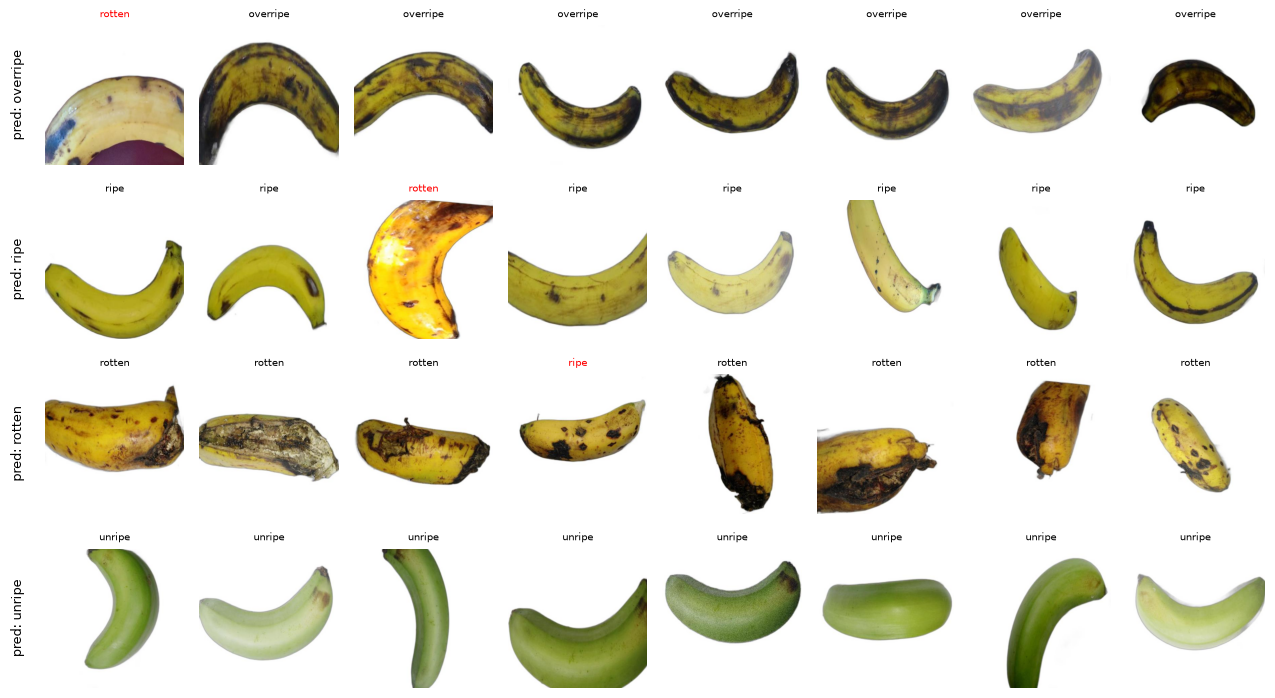

In [52]:
# eyeball: random samples per predicted cluster (title = true label, red = mismatch)
import matplotlib.pyplot as plt

N_SHOW = 8
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(len(classes), N_SHOW, figsize=(1.6 * N_SHOW, 1.8 * len(classes)))
for row, c in zip(axes, classes):
    idx = rng.choice(np.flatnonzero(y_final == c), size=N_SHOW, replace=False)
    for ax, i in zip(row, idx):
        ax.imshow(Image.open(paths[i]))
        ax.set_title(y[i], fontsize=7, color="black" if y[i] == c else "red")
        ax.axis("off")
    row[0].text(-0.15, 0.5, f"pred: {c}", transform=row[0].transAxes, rotation=90, va="center", ha="right", fontsize=9)
plt.tight_layout(); plt.show()